In [1]:
import torch


# GPU 정보 확인
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"총 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"할당된 메모리: {torch.cuda.memory_allocated() / 1e6:.1f} MB")
print(f"캐시된 메모리: {torch.cuda.memory_reserved() / 1e6:.1f} MB")


# 메모리 해제
torch.cuda.empty_cache()

GPU: NVIDIA GeForce RTX 4070
총 메모리: 12.4 GB
할당된 메모리: 0.0 MB
캐시된 메모리: 0.0 MB


In [2]:
import torch

print(torch.cuda.is_available())

def print_tensor_state(x):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(device)
    print(x.shape) # 크기
    print(x.dtype) # 데이터 타입 (float32, int64 등)
    print(x.device) # cpu 또는 cuda:0

x = torch.zeros(3, 4)
print_tensor_state(x)
x = torch.ones(3, 4)
print_tensor_state(x)
x = torch.randn(3, 4)
print_tensor_state(x)
x = torch.tensor([1, 2, 3])
print_tensor_state(x)
x = torch.arange(0, 10, 2)
print_tensor_state(x)




True
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3])
torch.int64
cuda:0
torch.Size([5])
torch.int64
cuda:0


In [3]:
a = torch.randn(3, 4)
print(f"a: {a}")
b = torch.randn(3, 4)
print(f"b: {b}")

c = a + b
print(f"c = a + b -> {c}")
c = a * b
print(f"c = a * b -> {c}")
c = a @ b.T
print(f"c = a @ b.T -> {c}")
c = torch.matmul(a, b.T)
print(f"c = torch.matmul(a, b.T) -> {c}")



a: tensor([[ 0.0433, -1.3863,  0.1527, -0.4547],
        [ 1.3204, -1.0859, -0.6857,  0.7579],
        [ 1.2991,  1.8314, -0.9383, -0.8325]])
b: tensor([[ 0.5858,  0.5141,  0.5427,  0.1677],
        [-0.5358, -0.0458,  1.1981,  0.2826],
        [ 0.9008,  0.6346, -1.3742,  0.1573]])
c = a + b -> tensor([[ 0.6292, -0.8722,  0.6954, -0.2870],
        [ 0.7847, -1.1317,  0.5124,  1.0405],
        [ 2.1999,  2.4660, -2.3125, -0.6753]])
c = a * b -> tensor([[ 0.0254, -0.7128,  0.0829, -0.0762],
        [-0.7074,  0.0497, -0.8216,  0.2142],
        [ 1.1702,  1.1622,  1.2894, -0.1309]])
c = a @ b.T -> tensor([[-0.6808,  0.0946, -1.1220],
        [-0.0299, -1.2650,  1.5618],
        [ 1.0538, -2.1393,  3.4908]])
c = torch.matmul(a, b.T) -> tensor([[-0.6808,  0.0946, -1.1220],
        [-0.0299, -1.2650,  1.5618],
        [ 1.0538, -2.1393,  3.4908]])


In [4]:
x = torch.randn(2, 3, 4)
print(f"x = {x.shape}")
print(f"x.view(2, 12) -> {x.view(2, 12).shape}")        # [2,3,4] -> [2,12] (메모리 연속 필요)
print(f"x.reshape(2, 12) -> {x.reshape(2, 12).shape}")  # [2,3,4] -> [2,12] (메모리 복사 가능)
print(f"x.permute(2, 0, 1) -> {x.permute(2, 0, 1).shape}")  # [2,3,4] -> [4,2,3]

y = torch.randn(3, 4)
print(f"y.unsqueeze(0) -> {y.unsqueeze(0).shape}")      # [3,4] -> [1,3,4]

z = torch.randn(1, 3, 4)
print(f"z.squeeze(0) -> {z.squeeze(0).shape}")          # [1,3,4] -> [3,4]

x = torch.Size([2, 3, 4])
x.view(2, 12) -> torch.Size([2, 12])
x.reshape(2, 12) -> torch.Size([2, 12])
x.permute(2, 0, 1) -> torch.Size([4, 2, 3])
y.unsqueeze(0) -> torch.Size([1, 3, 4])
z.squeeze(0) -> torch.Size([3, 4])


In [5]:
import numpy as np
img_np = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0

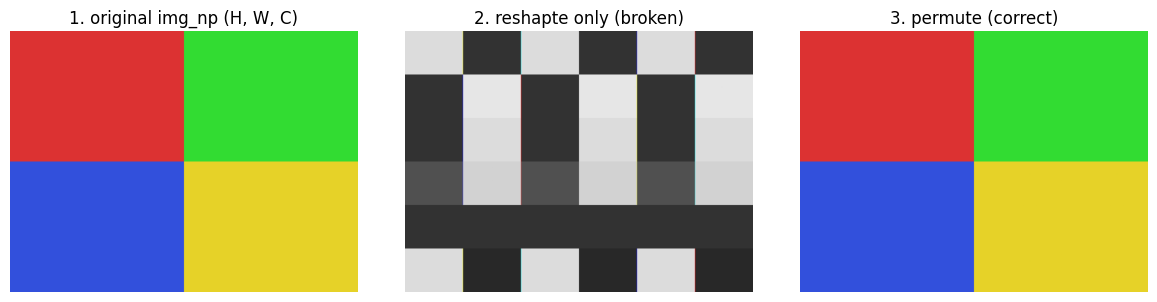

In [8]:
import matplotlib.pyplot as plt

H, W = 480, 640
img_np = np.zeros((H, W, 3), dtype=np.uint8)
img_np[: H // 2, : W // 2] = [220, 50, 50]
img_np[: H // 2, W // 2 :] = [50, 220, 50]
img_np[H // 2 :, : W // 2] = [50, 80, 220]
img_np[H // 2 :, W // 2 :] = [230, 210, 40]

img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("1. original img_np (H, W, C)")
plt.axis("off")

wrong = img_tensor.reshape(H, W, 3).cpu().numpy()
plt.subplot(1, 3, 2)
plt.imshow(wrong)
plt.title("2. reshapte only (broken)")
plt.axis("off")

img_back = img_tensor.permute(1, 2, 0).cpu().numpy()
plt.subplot(1, 3, 3)
plt.imshow(img_back)
plt.title("3. permute (correct)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
import torch
x = torch.tensor([2.0, 3.0], requires_grad=True)
w = torch.tensor([1.0, -1.0], requires_grad=True)

y = x * w
loss = y.sum()

loss.backward()

print(x.grad)
print(w.grad)

tensor([ 1., -1.])
tensor([2., 3.])
